## Verifying correctness of variational equation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Black Scholes closed

In [2]:
from black_scholes.bs import BlackScholes
from neural_network.config import MarketParams

In [3]:
S0 = 1.0
K = 1.0
T = 1.0
r = 0.05
sigma = 0.2

market_params = MarketParams(n_assets=1, S0=S0, K=K, T=T, r=r, sigma=sigma)

option_type = "put"
bs_closed = BlackScholes(market_params, option_type)

In [4]:
dS = 1e-6
dt = 1e-6

# Grid
S0_min = S0 * 0.5
S0_max = S0 * 2
t_min = 0
t_max = T - 2 * dt

resolution = 100
S_vals = np.linspace(S0_min + dS, S0_max - dS, resolution)
t_vals = np.linspace(t_min, t_max, resolution)

residual_grid = np.zeros((len(t_vals), len(S_vals)))

f = lambda t, S: bs_closed.price(t, S)

for i, t in enumerate(t_vals):
    for j, S in enumerate(S_vals):
        u = f(t, S)

        u_forward = f(t + dt, S)
        u_t = (u_forward - u) / dt

        u_S = (f(t, S + dS) - f(t, S - dS)) / (2*dS)
        u_SS = (f(t, S + dS) - 2*u + f(t, S - dS)) / (dS**2)

        residual_grid[i, j] = r * u - u_t - r * S * u_S - 0.5 * sigma**2 * S**2 * u_SS


/var/folders/yc/lmxhkkxd611c8bx7dqjsmvr40000gn/T/ipykernel_16875/3199296861.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  residual_grid[i, j] = r * u - u_t - r * S * u_S - 0.5 * sigma**2 * S**2 * u_SS


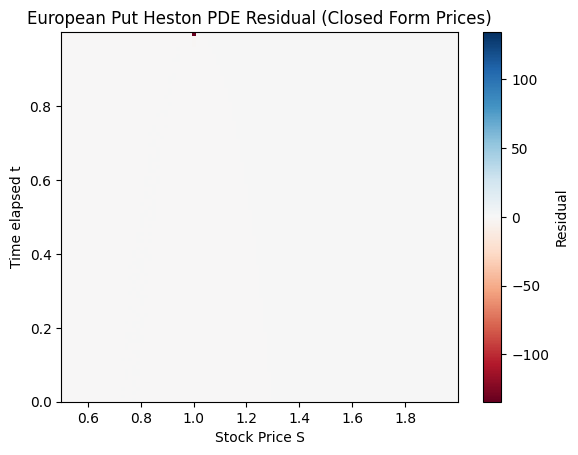

In [6]:
plt.figure()

v_max = np.abs(residual_grid).max()
v_min = -v_max

plt.imshow(residual_grid, aspect='auto',
           extent=[S_vals.min(), S_vals.max(), t_vals.min(), t_vals.max()],
           origin='lower', cmap='RdBu', vmin=v_min, vmax=v_max)
plt.xlabel("Stock Price S")
plt.ylabel("Time elapsed t")
plt.title("European Put Heston PDE Residual (Closed Form Prices)")
plt.colorbar(label="Residual")
plt.show()

### Heston closed

In [7]:
from heston.closed import HestonClosed

In [8]:
S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation

option_type = "put"
heston_closed = HestonClosed(K, r, T, kappa, theta, sigma, rho)

In [9]:
dS = 1e-6
dV = 1e-6
dt = 1e-6

# Grid
V0_min = 0.01
V0_max = 0.3
S0_min = S0 * 0.5
S0_max = S0 * 1.5
resolution = 40
S_vals = np.linspace(S0_min + dS, S0_max - dS, resolution)
V_vals = np.linspace(V0_min + dV, V0_max - dV, resolution)

residual_grid = np.zeros((len(V_vals), len(S_vals)))

ut_grid = np.zeros_like(residual_grid)
Lu_grid = np.zeros_like(residual_grid)
ru_grid = np.zeros_like(residual_grid)

f = lambda V, S: heston_closed.price(V, S)

for i, V in enumerate(V_vals):
    for j, S in enumerate(S_vals):
        u = f(V, S)

        u_forward = heston_closed.price(V, S, t=dt)
        u_t = (u_forward - u) / dt

        u_S = (f(V, S + dS) - f(V, S - dS)) / (2*dS)
        u_V = (f(V + dV, S) - f(V - dV, S)) / (2*dV)

        u_SS = (f(V, S + dS) - 2*u + f(V, S - dS)) / (dS**2)
        u_VV = (f(V + dV, S) - 2*u + f(V - dV, S)) / (dV**2)

        u_SV = (
            f(V + dV, S + dS)
            - f(V + dV, S - dS)
            - f(V - dV, S + dS)
            + f(V - dV, S - dS)
        ) / (4*dS*dV)

        Lu = (
            r * S * u_S
            + kappa * (theta - V) * u_V
            + 0.5 * (
                S**2 * V * u_SS
                + 2 * rho *sigma * S * V * u_SV
                + sigma**2 * V * u_VV
            )
        )

        ut_grid[i, j] = u_t
        Lu_grid[i, j] = Lu
        ru_grid[i, j] = r * u

        residual_grid[i, j] = r * u - u_t + Lu


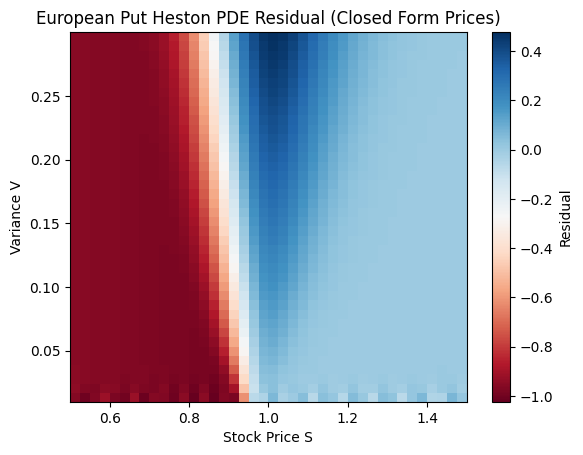

In [10]:
# Single heatmap
plt.figure()
plt.imshow(residual_grid, aspect='auto',
           extent=[S_vals.min(), S_vals.max(), V_vals.min(), V_vals.max()],
           origin='lower', cmap='RdBu')
plt.xlabel("Stock Price S")
plt.ylabel("Variance V")
plt.title("European Put Heston PDE Residual (Closed Form Prices)")
plt.colorbar(label="Residual")
plt.show()

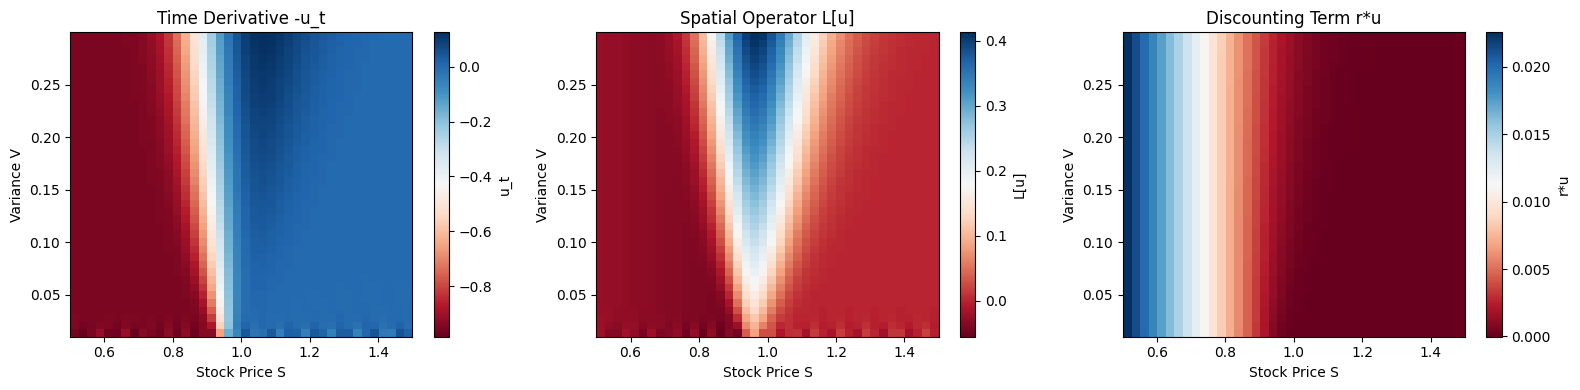

In [11]:
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
plt.imshow(-ut_grid, aspect='auto',
           extent=[S_vals.min(), S_vals.max(), V_vals.min(), V_vals.max()],
           origin='lower', cmap='RdBu')
plt.xlabel("Stock Price S")
plt.ylabel("Variance V")
plt.title("Time Derivative -u_t")
plt.colorbar(label="u_t")

plt.subplot(1, 3, 2)
plt.imshow(Lu_grid, aspect='auto',
           extent=[S_vals.min(), S_vals.max(), V_vals.min(), V_vals.max()],
           origin='lower', cmap='RdBu')
plt.xlabel("Stock Price S")
plt.ylabel("Variance V")
plt.title("Spatial Operator L[u]")
plt.colorbar(label="L[u]")

plt.subplot(1, 3, 3)
plt.imshow(ru_grid, aspect='auto',
           extent=[S_vals.min(), S_vals.max(), V_vals.min(), V_vals.max()],
           origin='lower', cmap='RdBu')
plt.xlabel("Stock Price S")
plt.ylabel("Variance V")
plt.title("Discounting Term r*u")
plt.colorbar(label="r*u")

plt.tight_layout()
plt.show()